In [85]:
import pandas as pd

In [86]:
df = pd.read_csv('dataset.csv')

# Проверка на дубликаты

In [87]:
df.duplicated().sum()

np.int64(0)

# Работа с пропусками

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17055 entries, 0 to 17054
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       17055 non-null  int64  
 1   url              17055 non-null  object 
 2   title            16998 non-null  object 
 3   year             16907 non-null  float64
 4   city             17055 non-null  object 
 5   make             17055 non-null  object 
 6   model            17055 non-null  object 
 7   price            16907 non-null  float64
 8   price_badge_raw  13628 non-null  object 
 9   price_badge      13628 non-null  object 
 10  published_date   16907 non-null  object 
 11  published_raw    16907 non-null  object 
 12  engine           16879 non-null  object 
 13  transmission     16886 non-null  object 
 14  mileage          14020 non-null  float64
 15  drive            16861 non-null  object 
 16  body             6790 non-null   object 
 17  color       

In [89]:
df = df.drop('Unnamed: 0', axis = 1)
df = df.drop('title', axis = 1)
df = df.drop('description', axis = 1)
df = df.drop('body', axis = 1)
df = df.drop('seller_type_raw', axis = 1)

In [90]:
df = df.dropna(subset = 'year')
df = df.dropna(subset = 'price')
df = df.dropna(subset = 'color')
df = df.dropna(subset = 'wheel')
df = df.dropna(subset = 'drive')
df = df.dropna(subset = 'transmission')
df = df.dropna(subset = 'engine')
df = df.dropna(subset = 'price_badge')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13113 entries, 0 to 17054
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              13113 non-null  object 
 1   year             13113 non-null  float64
 2   city             13113 non-null  object 
 3   make             13113 non-null  object 
 4   model            13113 non-null  object 
 5   price            13113 non-null  float64
 6   price_badge_raw  13113 non-null  object 
 7   price_badge      13113 non-null  object 
 8   published_date   13113 non-null  object 
 9   published_raw    13113 non-null  object 
 10  engine           13113 non-null  object 
 11  transmission     13113 non-null  object 
 12  mileage          13052 non-null  float64
 13  drive            13113 non-null  object 
 14  color            13113 non-null  object 
 15  wheel            13113 non-null  object 
 16  hp               13109 non-null  float64
 17  seller_type      

In [92]:
df.head(1)

,url,year,city,make,model,price,price_badge_raw,price_badge,published_date,published_raw,engine,transmission,mileage,drive,color,wheel,hp,seller_type,owner_status,is_owner
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая цена,хорошая,22.05.2026,Объявление 687313134 от 22.05.2026 33,"бензин, 2.0 л",АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True


так как price_badge_raw и price_badge показывают одно и то же, а именно рейтинг цены, то оставим только один признак

Аналогично с published_date и published_raw, которые также показывают одно и то же, а именно дату публикации объявления

In [93]:
df = df.drop('price_badge_raw', axis = 1)
df = df.drop('published_raw', axis = 1)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13113 entries, 0 to 17054
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13113 non-null  object 
 1   year            13113 non-null  float64
 2   city            13113 non-null  object 
 3   make            13113 non-null  object 
 4   model           13113 non-null  object 
 5   price           13113 non-null  float64
 6   price_badge     13113 non-null  object 
 7   published_date  13113 non-null  object 
 8   engine          13113 non-null  object 
 9   transmission    13113 non-null  object 
 10  mileage         13052 non-null  float64
 11  drive           13113 non-null  object 
 12  color           13113 non-null  object 
 13  wheel           13113 non-null  object 
 14  hp              13109 non-null  float64
 15  seller_type     13113 non-null  object 
 16  owner_status    2760 non-null   object 
 17  is_owner        2760 non-null   obje

В owner_status NaN это не пропуск, а сигнал о том, что человек не собственник, так как просто плашки собственника у него на страничке нет и поэтому ему прописывается NaN. Так что все пропуски в owner_status и is_owner (что показывает одно и то же, только первое буквами, а второе закодированно) заменим на "не собственник" и False

In [95]:
df['owner_status'] = df['owner_status'].fillna('не собственник')
df['is_owner'] = df['is_owner'].fillna(False)

/tmp/ipykernel_6071/4304185.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_owner'] = df['is_owner'].fillna(False)


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13113 entries, 0 to 17054
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13113 non-null  object 
 1   year            13113 non-null  float64
 2   city            13113 non-null  object 
 3   make            13113 non-null  object 
 4   model           13113 non-null  object 
 5   price           13113 non-null  float64
 6   price_badge     13113 non-null  object 
 7   published_date  13113 non-null  object 
 8   engine          13113 non-null  object 
 9   transmission    13113 non-null  object 
 10  mileage         13052 non-null  float64
 11  drive           13113 non-null  object 
 12  color           13113 non-null  object 
 13  wheel           13113 non-null  object 
 14  hp              13109 non-null  float64
 15  seller_type     13113 non-null  object 
 16  owner_status    13113 non-null  object 
 17  is_owner        13113 non-null  bool

Заполним пробег(mileage)медианным значением по марке+модели+году

In [97]:
mileage_table = df.groupby(['make', 'model', 'year'])['mileage'].median()

In [98]:
mileage_table.head(3)

make  model  year  
audi  100    1984.0    252500.0
             1988.0    399999.5
             1989.0    377500.0
Name: mileage, dtype: float64

In [99]:
df = df.merge(mileage_table, on = ['make', 'model', 'year'], how = 'left')

In [100]:
df.head(1)

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,mileage_x,drive,color,wheel,hp,seller_type,owner_status,is_owner,mileage_y
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True,121000.0


In [101]:
df['mileage_x'] = df['mileage_x'].fillna(df['mileage_y'])

In [102]:
df = df.drop('mileage_y', axis = 1)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13113 entries, 0 to 13112
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13113 non-null  object 
 1   year            13113 non-null  float64
 2   city            13113 non-null  object 
 3   make            13113 non-null  object 
 4   model           13113 non-null  object 
 5   price           13113 non-null  float64
 6   price_badge     13113 non-null  object 
 7   published_date  13113 non-null  object 
 8   engine          13113 non-null  object 
 9   transmission    13113 non-null  object 
 10  mileage_x       13105 non-null  float64
 11  drive           13113 non-null  object 
 12  color           13113 non-null  object 
 13  wheel           13113 non-null  object 
 14  hp              13109 non-null  float64
 15  seller_type     13113 non-null  object 
 16  owner_status    13113 non-null  object 
 17  is_owner        13113 non-null 

Не так много всего получилось заполнить, остальные строки удаляем

In [104]:
df = df.dropna(subset = 'mileage_x')

In [105]:
df = df.rename(columns = {'mileage_x': 'mileage'})

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13105 entries, 0 to 13112
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13105 non-null  object 
 1   year            13105 non-null  float64
 2   city            13105 non-null  object 
 3   make            13105 non-null  object 
 4   model           13105 non-null  object 
 5   price           13105 non-null  float64
 6   price_badge     13105 non-null  object 
 7   published_date  13105 non-null  object 
 8   engine          13105 non-null  object 
 9   transmission    13105 non-null  object 
 10  mileage         13105 non-null  float64
 11  drive           13105 non-null  object 
 12  color           13105 non-null  object 
 13  wheel           13105 non-null  object 
 14  hp              13101 non-null  float64
 15  seller_type     13105 non-null  object 
 16  owner_status    13105 non-null  object 
 17  is_owner        13105 non-null  bool

In [107]:
hp_table = df.groupby(['make', 'model', 'year'])['hp'].median()

In [108]:
hp_table.head(1)

,,,hp
make,model,year,
audi,100,1984.0,75.0


In [109]:
df = df.merge(hp_table, on = ['make', 'model', 'year'], how = 'left')
df['hp_x'] = df['hp_x'].fillna(df['hp_y'])
df = df.drop('hp_y', axis = 1)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13105 entries, 0 to 13104
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13105 non-null  object 
 1   year            13105 non-null  float64
 2   city            13105 non-null  object 
 3   make            13105 non-null  object 
 4   model           13105 non-null  object 
 5   price           13105 non-null  float64
 6   price_badge     13105 non-null  object 
 7   published_date  13105 non-null  object 
 8   engine          13105 non-null  object 
 9   transmission    13105 non-null  object 
 10  mileage         13105 non-null  float64
 11  drive           13105 non-null  object 
 12  color           13105 non-null  object 
 13  wheel           13105 non-null  object 
 14  hp_x            13102 non-null  float64
 15  seller_type     13105 non-null  object 
 16  owner_status    13105 non-null  object 
 17  is_owner        13105 non-null 

In [111]:
df = df.dropna(subset = 'hp_x')
df = df.rename(columns = {'hp_x': 'hp'})

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13102 entries, 0 to 13104
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   url             13102 non-null  object 
 1   year            13102 non-null  float64
 2   city            13102 non-null  object 
 3   make            13102 non-null  object 
 4   model           13102 non-null  object 
 5   price           13102 non-null  float64
 6   price_badge     13102 non-null  object 
 7   published_date  13102 non-null  object 
 8   engine          13102 non-null  object 
 9   transmission    13102 non-null  object 
 10  mileage         13102 non-null  float64
 11  drive           13102 non-null  object 
 12  color           13102 non-null  object 
 13  wheel           13102 non-null  object 
 14  hp              13102 non-null  float64
 15  seller_type     13102 non-null  object 
 16  owner_status    13102 non-null  object 
 17  is_owner        13102 non-null  bool

Пропуски очищены!

In [113]:
df.head()

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,mileage,drive,color,wheel,hp,seller_type,owner_status,is_owner
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True
1,https://auto.drom.ru/ulyanovsk/kia/rio/3147446...,2020.0,ulyanovsk,kia,rio,1696000.0,нормальная,23.05.2026,"бензин, 1.6 л",АКПП,61331.0,передний,белый,левый,123.0,компания,не собственник,False
2,https://auto.drom.ru/novosibirsk/toyota/rav4/8...,2011.0,novosibirsk,toyota,rav4,1359000.0,хорошая,23.05.2026,"бензин, 2.0 л",вариатор,148000.0,4WD,серебристый,левый,148.0,компания,не собственник,False
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,122000.0,4WD,серый,левый,150.0,компания,не собственник,False
4,https://auto.drom.ru/saratov/kia/cerato/621404...,2007.0,saratov,kia,cerato,530000.0,высокая,23.05.2026,"бензин, 1.6 л",механика,191810.0,передний,красный,левый,122.0,компания,не собственник,False


# Гипотеза 1

**Гипотеза**

У дилеров цена выше, чем у частных продавцов

In [114]:
df['price'].dtype

dtype('float64')

In [115]:
df['avg_price'] = df.groupby(['make', 'model', 'year'])['price'].transform('mean')

In [116]:
df.head()

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,mileage,drive,color,wheel,hp,seller_type,owner_status,is_owner,avg_price
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,66000.0,передний,белый,левый,150.0,частник,собственник,True,2.188812e+06
1,https://auto.drom.ru/ulyanovsk/kia/rio/3147446...,2020.0,ulyanovsk,kia,rio,1696000.0,нормальная,23.05.2026,"бензин, 1.6 л",АКПП,61331.0,передний,белый,левый,123.0,компания,не собственник,False,1.450606e+06
2,https://auto.drom.ru/novosibirsk/toyota/rav4/8...,2011.0,novosibirsk,toyota,rav4,1359000.0,хорошая,23.05.2026,"бензин, 2.0 л",вариатор,148000.0,4WD,серебристый,левый,148.0,компания,не собственник,False,1.463833e+06
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,122000.0,4WD,серый,левый,150.0,компания,не собственник,False,2.188812e+06
4,https://auto.drom.ru/saratov/kia/cerato/621404...,2007.0,saratov,kia,cerato,530000.0,высокая,23.05.2026,"бензин, 1.6 л",механика,191810.0,передний,красный,левый,122.0,компания,не собственник,False,4.062500e+05


In [117]:
df['price_coef'] = df['price'] / df['avg_price']

In [118]:
df['bin'] = (df['year'] // 5) * 5

In [119]:
df['group_count'] = df.groupby(['make', 'model', 'bin'])['price'].transform('count')

In [120]:
df.head()

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,...,color,wheel,hp,seller_type,owner_status,is_owner,avg_price,price_coef,bin,group_count
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,...,белый,левый,150.0,частник,собственник,True,2.188812e+06,0.958967,2015.0,54
1,https://auto.drom.ru/ulyanovsk/kia/rio/3147446...,2020.0,ulyanovsk,kia,rio,1696000.0,нормальная,23.05.2026,"бензин, 1.6 л",АКПП,...,белый,левый,123.0,компания,не собственник,False,1.450606e+06,1.169166,2020.0,17
2,https://auto.drom.ru/novosibirsk/toyota/rav4/8...,2011.0,novosibirsk,toyota,rav4,1359000.0,хорошая,23.05.2026,"бензин, 2.0 л",вариатор,...,серебристый,левый,148.0,компания,не собственник,False,1.463833e+06,0.928384,2010.0,20
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,...,серый,левый,150.0,компания,не собственник,False,2.188812e+06,1.004654,2015.0,54
4,https://auto.drom.ru/saratov/kia/cerato/621404...,2007.0,saratov,kia,cerato,530000.0,высокая,23.05.2026,"бензин, 1.6 л",механика,...,красный,левый,122.0,компания,не собственник,False,4.062500e+05,1.304615,2005.0,8


In [121]:
df[df['group_count'] > 40]

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,...,color,wheel,hp,seller_type,owner_status,is_owner,avg_price,price_coef,bin,group_count
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,...,белый,левый,150.0,частник,собственник,True,2.188812e+06,0.958967,2015.0,54
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,...,серый,левый,150.0,компания,не собственник,False,2.188812e+06,1.004654,2015.0,54
9,https://auto.drom.ru/saratov/kia/rio/566186852...,2014.0,saratov,kia,rio,850000.0,нормальная,22.05.2026,"бензин, 1.6 л",АКПП,...,синий,левый,123.0,компания,не собственник,False,7.514308e+05,1.131175,2010.0,62
12,https://auto.drom.ru/chita/cheryexeed/lx/83997...,2022.0,chita,cheryexeed,lx,1900000.0,нормальная,22.05.2026,"бензин, 1.5 л",вариатор,...,серый,левый,156.0,частник,не собственник,False,1.932173e+06,0.983349,2020.0,84
13,https://auto.drom.ru/nizhniy-novgorod/kia/rio/...,2010.0,nizhniy-novgorod,kia,rio,489999.0,нормальная,22.05.2026,"бензин, 1.4 л",механика,...,серебристый,левый,95.0,частник,не собственник,False,5.275998e+05,0.928732,2010.0,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,https://auto.drom.ru/kaliningrad/skoda/octavia...,2008.0,kaliningrad,skoda,octavia,550000.0,высокая,22.05.2026,"бензин, 1.4 л",механика,...,красный,левый,75.0,частник,не собственник,False,4.903846e+05,1.121569,2005.0,57
13095,https://auto.drom.ru/novosibirsk/skoda/rapid/8...,2015.0,novosibirsk,skoda,rapid,1077000.0,высокая,21.05.2026,"бензин, 1.6 л",механика,...,белый,левый,105.0,частник,не собственник,False,8.152857e+05,1.321009,2015.0,90
13096,https://auto.drom.ru/izhevsk/chery/tiggo_7_pro...,2024.0,izhevsk,chery,tiggo_7_pro_max,2400000.0,нормальная,21.05.2026,"бензин, 1.6 л",робот,...,серебристый,левый,150.0,компания,собственник,True,2.101568e+06,1.142005,2020.0,101
13099,https://auto.drom.ru/moscow/mercedes-benz/e-cl...,2010.0,moscow,mercedes-benz,e-class,1310000.0,хорошая,22.05.2026,"бензин, 1.8 л",АКПП,...,голубой,левый,204.0,компания,собственник,True,1.542714e+06,0.849153,2010.0,51


In [122]:
df_test1 = df[df['group_count'] > 40]

Итак, мы собрали подвыборку для автомобилей, которых в разрезе марки, модели и промежутку 5 лет было от 40 в группе. Таких мы получили 3700, что немало.   
Также мы посчитали price_coef, который указывает на коэффициент цены, относительно средней цены в разрезе марки, модели и промежутку 5 лет.

In [123]:
import matplotlib.pyplot as plt

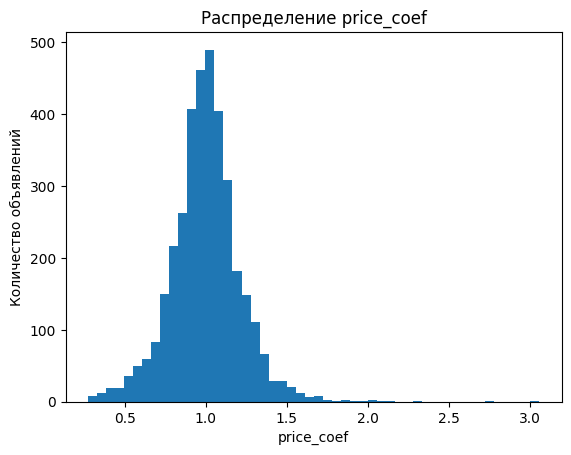

In [124]:
plt.hist(df_test1['price_coef'], bins=50)

plt.title('Распределение price_coef')
plt.xlabel('price_coef')
plt.ylabel('Количество объявлений')

plt.show()

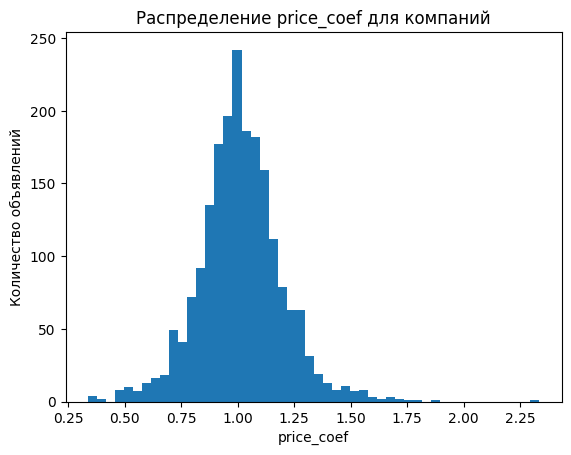

In [125]:
plt.hist(df_test1[df_test1['seller_type'] == 'компания']['price_coef'], bins=50)

plt.title('Распределение price_coef для компаний')
plt.xlabel('price_coef')
plt.ylabel('Количество объявлений')

plt.show()

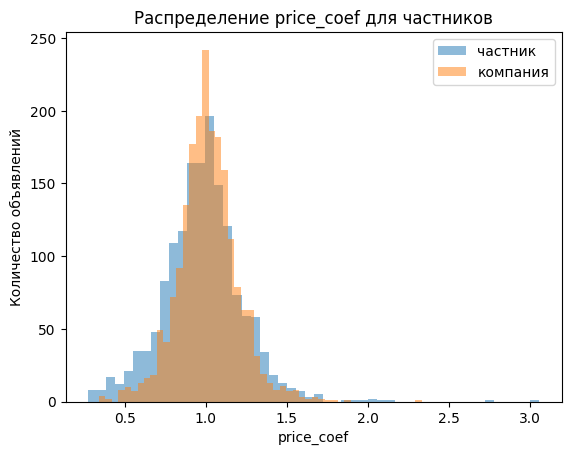

In [126]:
plt.hist(df_test1[df_test1['seller_type'] == 'частник']['price_coef'], bins=50, alpha = 0.5, label = 'частник')
plt.hist(df_test1[df_test1['seller_type'] == 'компания']['price_coef'], bins=50, alpha = 0.5, label = 'компания')


plt.title('Распределение price_coef для частников')
plt.xlabel('price_coef')
plt.ylabel('Количество объявлений')

plt.legend()
plt.show()

Теперь давайте проверим нормальность данных

Text(0.5, 1.0, 'Сравнение распределения price_coef для частников с нормальным распределением')

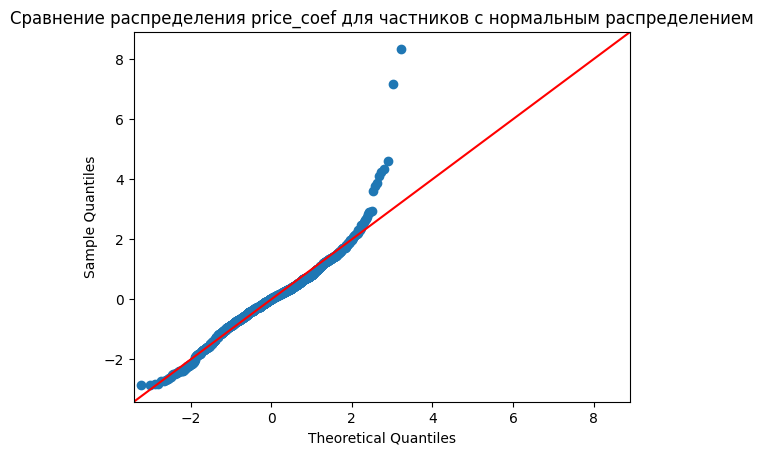

In [127]:
from statsmodels.api import qqplot
from scipy.stats import norm

fig = qqplot(df_test1[df_test1['seller_type'] == 'частник']['price_coef'], norm, line='45', fit=True)
plt.title('Сравнение распределения price_coef для частников с нормальным распределением')

Text(0.5, 1.0, 'Сравнение распределения price_coef для компаний с нормальным распределением')

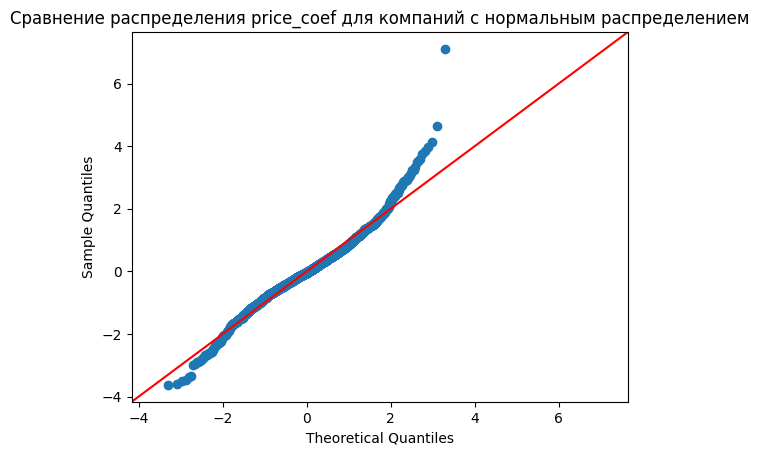

In [128]:
from statsmodels.api import qqplot
from scipy.stats import norm

fig = qqplot(df_test1[df_test1['seller_type'] == 'компания']['price_coef'], norm, line='45', fit=True)
plt.title('Сравнение распределения price_coef для компаний с нормальным распределением')

Смущают хвосты и выбросы. В центре все неплохо, но к краям начинается отклонение. Давайте проверим через тест Шапиро, который проверяет данные на нормальность.   

Итак, для теста установим уровень значимости 0.05.  
H0 - Данные распределены нормально.   
H1 - Данные распределены ненормально.  



In [129]:
from scipy.stats import shapiro

shapiro(df_test1['price_coef'])

ShapiroResult(statistic=np.float64(0.9599503250288492), pvalue=np.float64(1.7722128538362133e-30))

Получили p < 0.05, поэтому можем сказать, что мы отвергаем нулевую гипотезу. Значит, данные распределены ненормально.

Используем тест Манна-Уитни, так как


*   данные распределены ненормально
*   две независимые группы
*   price_coef является количественным признаком


уровень значимости = 0.05.   
H0 - распределения price_coef для частников и компаний одинаковые.  
H1 - распределения price_coef для частников и компаний разные

In [130]:
from scipy.stats import mannwhitneyu

owner = df_test1[df_test1['seller_type'] == 'частник']['price_coef']
company = df_test1[df_test1['seller_type'] == 'компания']['price_coef']

stat, p_value = mannwhitneyu(owner, company)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 1466810.5, p-значение: 9.938658598063285e-06


In [142]:
print('Срдений price_coef для частников:', owner.mean())
print('Срдений price_coef для компаний:', company.mean())

Срдений price_coef для частников: 0.9830474219286024
Срдений price_coef для компаний: 1.0131076634572664


Итак, в результате теста получили p < 0.05, поэтому можем отвергнуть нулевую гипотезу. То есть распределения price_coef для частников и компаний разные. Теперь проверим, что у компаний оно выше.

Проверим тестом, что у компаний цена больше, чем у частников.   
Уровень значимости = 0.05.   
H0 - price_coef для компаний < чем у частников    
H1 - price_coef для компаний > чем у частников

In [132]:
from scipy.stats import mannwhitneyu

owner = df_test1[df_test1['seller_type'] == 'частник']['price_coef']
company = df_test1[df_test1['seller_type'] == 'компания']['price_coef']

stat, p_value = mannwhitneyu(company, owner, alternative='greater')

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 1741464.5, p-значение: 4.969329299031642e-06


Итак, p < 0.05, значит отвергаем нулевую гипотезу. Значит, что у компаний цена на авто статистически больше, чем у частников.

**Итог теста 1**

Компании выставляют машины по рынку дороже, чем частники. Тесты в разрезе цен для марки, модели и промежутке 5 лет показали статистически значимые результаты.

# Гипотеза 2

Теперь давайте проверим гипотезу, что распределение цен для Москвы, СПБ и регионов отличается.

In [133]:
df_test1

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,...,color,wheel,hp,seller_type,owner_status,is_owner,avg_price,price_coef,bin,group_count
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,...,белый,левый,150.0,частник,собственник,True,2.188812e+06,0.958967,2015.0,54
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,...,серый,левый,150.0,компания,не собственник,False,2.188812e+06,1.004654,2015.0,54
9,https://auto.drom.ru/saratov/kia/rio/566186852...,2014.0,saratov,kia,rio,850000.0,нормальная,22.05.2026,"бензин, 1.6 л",АКПП,...,синий,левый,123.0,компания,не собственник,False,7.514308e+05,1.131175,2010.0,62
12,https://auto.drom.ru/chita/cheryexeed/lx/83997...,2022.0,chita,cheryexeed,lx,1900000.0,нормальная,22.05.2026,"бензин, 1.5 л",вариатор,...,серый,левый,156.0,частник,не собственник,False,1.932173e+06,0.983349,2020.0,84
13,https://auto.drom.ru/nizhniy-novgorod/kia/rio/...,2010.0,nizhniy-novgorod,kia,rio,489999.0,нормальная,22.05.2026,"бензин, 1.4 л",механика,...,серебристый,левый,95.0,частник,не собственник,False,5.275998e+05,0.928732,2010.0,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,https://auto.drom.ru/kaliningrad/skoda/octavia...,2008.0,kaliningrad,skoda,octavia,550000.0,высокая,22.05.2026,"бензин, 1.4 л",механика,...,красный,левый,75.0,частник,не собственник,False,4.903846e+05,1.121569,2005.0,57
13095,https://auto.drom.ru/novosibirsk/skoda/rapid/8...,2015.0,novosibirsk,skoda,rapid,1077000.0,высокая,21.05.2026,"бензин, 1.6 л",механика,...,белый,левый,105.0,частник,не собственник,False,8.152857e+05,1.321009,2015.0,90
13096,https://auto.drom.ru/izhevsk/chery/tiggo_7_pro...,2024.0,izhevsk,chery,tiggo_7_pro_max,2400000.0,нормальная,21.05.2026,"бензин, 1.6 л",робот,...,серебристый,левый,150.0,компания,собственник,True,2.101568e+06,1.142005,2020.0,101
13099,https://auto.drom.ru/moscow/mercedes-benz/e-cl...,2010.0,moscow,mercedes-benz,e-class,1310000.0,хорошая,22.05.2026,"бензин, 1.8 л",АКПП,...,голубой,левый,204.0,компания,собственник,True,1.542714e+06,0.849153,2010.0,51


In [134]:
df_test2 = df_test1.copy()

In [135]:
df_test2['region_type'] = 'Регионы'

In [136]:
df_test2.loc[df_test2['city'] == 'moscow', 'region_type'] = 'МСК'
df_test2.loc[df_test2['city'] == 'spb', 'region_type'] = 'СПБ'

In [137]:
df_test2

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,...,wheel,hp,seller_type,owner_status,is_owner,avg_price,price_coef,bin,group_count,region_type
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,...,левый,150.0,частник,собственник,True,2.188812e+06,0.958967,2015.0,54,Регионы
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,...,левый,150.0,компания,не собственник,False,2.188812e+06,1.004654,2015.0,54,Регионы
9,https://auto.drom.ru/saratov/kia/rio/566186852...,2014.0,saratov,kia,rio,850000.0,нормальная,22.05.2026,"бензин, 1.6 л",АКПП,...,левый,123.0,компания,не собственник,False,7.514308e+05,1.131175,2010.0,62,Регионы
12,https://auto.drom.ru/chita/cheryexeed/lx/83997...,2022.0,chita,cheryexeed,lx,1900000.0,нормальная,22.05.2026,"бензин, 1.5 л",вариатор,...,левый,156.0,частник,не собственник,False,1.932173e+06,0.983349,2020.0,84,Регионы
13,https://auto.drom.ru/nizhniy-novgorod/kia/rio/...,2010.0,nizhniy-novgorod,kia,rio,489999.0,нормальная,22.05.2026,"бензин, 1.4 л",механика,...,левый,95.0,частник,не собственник,False,5.275998e+05,0.928732,2010.0,62,Регионы
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,https://auto.drom.ru/kaliningrad/skoda/octavia...,2008.0,kaliningrad,skoda,octavia,550000.0,высокая,22.05.2026,"бензин, 1.4 л",механика,...,левый,75.0,частник,не собственник,False,4.903846e+05,1.121569,2005.0,57,Регионы
13095,https://auto.drom.ru/novosibirsk/skoda/rapid/8...,2015.0,novosibirsk,skoda,rapid,1077000.0,высокая,21.05.2026,"бензин, 1.6 л",механика,...,левый,105.0,частник,не собственник,False,8.152857e+05,1.321009,2015.0,90,Регионы
13096,https://auto.drom.ru/izhevsk/chery/tiggo_7_pro...,2024.0,izhevsk,chery,tiggo_7_pro_max,2400000.0,нормальная,21.05.2026,"бензин, 1.6 л",робот,...,левый,150.0,компания,собственник,True,2.101568e+06,1.142005,2020.0,101,Регионы
13099,https://auto.drom.ru/moscow/mercedes-benz/e-cl...,2010.0,moscow,mercedes-benz,e-class,1310000.0,хорошая,22.05.2026,"бензин, 1.8 л",АКПП,...,левый,204.0,компания,собственник,True,1.542714e+06,0.849153,2010.0,51,МСК


In [138]:
df_test2.groupby('region_type').size()

,0
region_type,
МСК,302
Регионы,3157
СПБ,153


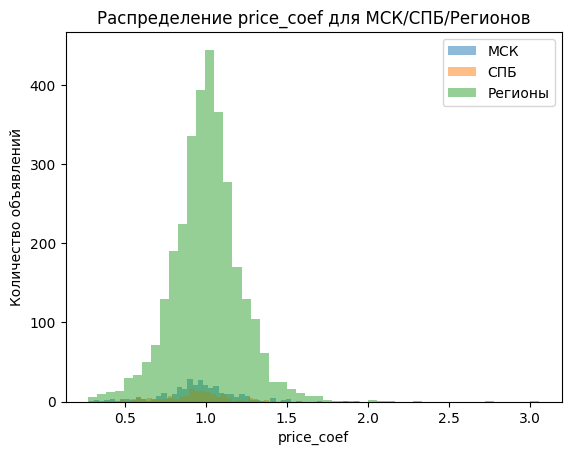

In [139]:
plt.hist(df_test2[df_test2['region_type'] == 'МСК']['price_coef'], bins=50, alpha = 0.5, label = 'МСК')
plt.hist(df_test2[df_test2['region_type'] == 'СПБ']['price_coef'], bins=50, alpha = 0.5, label = 'СПБ')
plt.hist(df_test2[df_test2['region_type'] == 'Регионы']['price_coef'], bins=50, alpha = 0.5, label = 'Регионы')


plt.title('Распределение price_coef для МСК/СПБ/Регионов')
plt.xlabel('price_coef')
plt.ylabel('Количество объявлений')

plt.legend()
plt.show()

В предыдущем гипотезе мы уже проверяли данные на нормальность. Как мы знаем, price_coef распределено не нормально. Поэтому для теста с несколькими группами будем использовать тест Крускала Воллиса.  
H0 - различий между распредлениями price_coef в МСК/СПБ/Регионах нет.   
H1 - различия в распределениях есть

In [140]:
MSK = df_test2[df_test2['region_type'] == 'МСК']['price_coef']
SPB = df_test2[df_test2['region_type'] == 'СПБ']['price_coef']
Regions = df_test2[df_test2['region_type'] == 'Регионы']['price_coef']

In [141]:
from scipy.stats import kruskal

stat, p_value = kruskal(MSK, SPB, Regions)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 30.79022429803254, p-значение: 2.060571768764272e-07


Итак, p < 0.05, значит отвергаем нулевую гипотезу. Значит, что распределение price_coef в одном или нескольких регионах среди МСК/СПБ/Регионах разные. Давайте проверим среднии, чтобы выяснить где цены выше/ниже

In [143]:
print('Срдений price_coef для МСК:', MSK.mean())
print('Срдений price_coef для СПБ:', SPB.mean())
print('Срдений price_coef для регионов:', Regions.mean())

Срдений price_coef для МСК: 0.9520262193979845
Срдений price_coef для СПБ: 0.9451684245190582
Срдений price_coef для регионов: 1.0072465355687021


Итак, кажется, что в регионе цена самая большая, далее идет Москва и СПБ

Давайте, чтобы точно понимать где больше/меньше цена попарно сравним через тест Манна-Уитни. Применяем как раньше, так как данные ненормальные.    
Для всех тестов уровнень значимости 0.05.  
Тест 1. В регионе цены выше, чем в Москве.   
H0 - цена в регионе меньше, чем в Москве.  
H1 - цена в регионе больше, чем в Москве.  
    
Тест 2. В регионе цены выше, чем в СПБ.   
H0 - цена в регионе меньше, чем в регионах.  
H1 - цена в регионе больше, чем в регионах.  
    
Тест 3. В Москве цены выше, чем в СПБ.   
H0 - цена в Москве меньше, чем в СПБ.  
H1 - цена в Москве больше, чем в СПБ.

In [144]:
stat, p_value = mannwhitneyu(Regions, MSK, alternative='greater')
print('Тест 1:')
print(f"Статистика теста 1: {stat}, p-значение: {p_value}")
print()

stat, p_value = mannwhitneyu(Regions, SPB, alternative='greater')
print('Тест 2:')
print(f"Статистика теста 2: {stat}, p-значение: {p_value}")
print()

stat, p_value = mannwhitneyu(MSK, SPB, alternative='greater')
print('Тест 3:')
print(f"Статистика теста 3: {stat}, p-значение: {p_value}")

Тест 1:
Статистика теста 1: 551120.5, p-значение: 3.593387036939645e-06

Тест 2:
Статистика теста 2: 282402.0, p-значение: 0.0001985083957381088

Тест 3:
Статистика теста 3: 23306.5, p-значение: 0.43912077789309273


Итак, статистически видим различия только для 1 и 2 теста, то есть там мы отвергли 0 гипотезу и получили, что в регионе цена выше, чем в Мск и СПБ. Но мы не можем сказать про успех теста 3: там нет оснований отклонить нулевую гипотезу.

На всякий промери Мск и СПБ между собой на различие средних. Как всегда уровень значимости 0.05. H0 - разлчиий в распределниях нет. H1 - различия в распределениях есть.

In [162]:
stat, p_value = mannwhitneyu(MSK, SPB)
print('Тест 4:')
print(f"Статистика теста 4: {stat}, p-значение: {p_value}")

Тест 4:
Статистика теста 4: 23306.5, p-значение: 0.8782415557861855


Получили p > 0.05. Поэтому нет оснований отклонить 0 гипотезу.

В финале можем сказать, что в регионе обычно машины стоят дороже, чем в МСК и Питере

# Гипотеза 3

Теперь проверим гипотезу о том, что авто от собственника чаще имеет плашку «хорошая/отличная цена»

In [146]:
df.head()

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,...,color,wheel,hp,seller_type,owner_status,is_owner,avg_price,price_coef,bin,group_count
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,...,белый,левый,150.0,частник,собственник,True,2.188812e+06,0.958967,2015.0,54
1,https://auto.drom.ru/ulyanovsk/kia/rio/3147446...,2020.0,ulyanovsk,kia,rio,1696000.0,нормальная,23.05.2026,"бензин, 1.6 л",АКПП,...,белый,левый,123.0,компания,не собственник,False,1.450606e+06,1.169166,2020.0,17
2,https://auto.drom.ru/novosibirsk/toyota/rav4/8...,2011.0,novosibirsk,toyota,rav4,1359000.0,хорошая,23.05.2026,"бензин, 2.0 л",вариатор,...,серебристый,левый,148.0,компания,не собственник,False,1.463833e+06,0.928384,2010.0,20
3,https://auto.drom.ru/ekaterinburg/kia/sportage...,2019.0,ekaterinburg,kia,sportage,2199000.0,нормальная,23.05.2026,"бензин, 2.0 л",АКПП,...,серый,левый,150.0,компания,не собственник,False,2.188812e+06,1.004654,2015.0,54
4,https://auto.drom.ru/saratov/kia/cerato/621404...,2007.0,saratov,kia,cerato,530000.0,высокая,23.05.2026,"бензин, 1.6 л",механика,...,красный,левый,122.0,компания,не собственник,False,4.062500e+05,1.304615,2005.0,8


In [148]:
df['price_badge'].unique()

array(['хорошая', 'нормальная', 'высокая', 'без оценки', 'отличная'],
      dtype=object)

In [150]:
df_test3 = df.copy()

In [151]:
df_test3 = df_test3[df_test3['price_badge'].isin(['хорошая', 'нормальная', 'высокая', 'отличная'])]

In [154]:
df_test3['good_price'] = df_test3['price_badge'].isin(['хорошая', 'отличная'])

In [155]:
df_test3.head(1)

,url,year,city,make,model,price,price_badge,published_date,engine,transmission,...,wheel,hp,seller_type,owner_status,is_owner,avg_price,price_coef,bin,group_count,good_price
0,https://auto.drom.ru/kemerovo/kia/sportage/687...,2019.0,kemerovo,kia,sportage,2099000.0,хорошая,22.05.2026,"бензин, 2.0 л",АКПП,...,левый,150.0,частник,собственник,True,2188812.5,0.958967,2015.0,54,True


Итак, установим уровень значимости 0.05.  
H0 - наличие оценки хорошая/отличная цена не зависит от плашки "собственник".   
H1 - наличие плашки хорошая/отличная цена зависит от плашки "собственник".  


In [160]:
df_test3.groupby(['owner_status','good_price'])['price_badge'].count().unstack()

good_price,False,True
owner_status,,
не собственник,7243,1776
собственник,2144,419


In [163]:
from scipy.stats import chi2_contingency

stat, p_value, dof, expected = chi2_contingency(df_test3.groupby(['owner_status','good_price'])['price_badge'].count().unstack())

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 14.310669516537784, p-значение: 0.00015498394663042788


Итак, p < 0.05, поэтому отклоняем нулевую гипотезу. Следовательно, наличие плашки хорошая/отличная цена зависит от плашки собственник.

In [168]:
test3 = df_test3.groupby(['owner_status','good_price'])['price_badge'].count().unstack()
test3['true_to_all'] = test3[True] / (test3[True] + test3[False])
test3

good_price,False,True,true_to_all
owner_status,,,
не собственник,7243,1776,0.196918
собственник,2144,419,0.163480


Получается, что если плашки собственника нет, то у объявления с большей вероятностью будет значок хорошая/отличная цена